# HD 189733 b Transit Photometry

**Author:** Biswajit Jana

This notebook uses **real public TESS light-curve data** to recover the transit of **HD 189733 b**.  
It starts from a simple one-sector workflow because that is the clearest way to make sure the transit is real and visible before attempting multi-sector stitching.

The notebook also lets people try other targets by changing the target settings near the top.

Workflow:

1. choose a target,
2. get archive planet/star values,
3. search available TESS products,
4. automatically pick a useful one-sector example,
5. fold the real TESS data,
6. measure the transit depth,
7. estimate simple physical properties from the dip.

## 1. Install packages

In [1]:
!pip -q install lightkurve pandas numpy matplotlib astropy

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.1/261.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 22.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.4.0 which is incompatible.
datasets 4.0.0 requ

## 2. Import libraries and set output folder

In [2]:
from pathlib import Path
from urllib.parse import quote
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import astropy.units as u
from astropy import constants as const

import lightkurve as lk

OUTDIR = Path("outputs")
OUTDIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": True,
    "font.size": 11
})

/usr/local/lib/python3.12/dist-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


## 3. Choose a target

The default is **HD 189733 b**.

To test another preset, change `TARGET_KEY`.  
To use your own target, set `CUSTOM_MODE = True` and edit `CUSTOM_TARGET`.

The notebook will test several TESS products, then choose the one that gives the clearest one-sector transit recovery.

In [3]:
TARGET_PRESETS = {
    "HD 189733 b": {
        "host": "HD 189733",
        "planet": "HD 189733 b",
        "manual_t0_bjd": 2453988.80336,
        "reference_depth_percent": 2.41,
        "notes": "Deep hot-Jupiter transit; good default target."
    },
    "HD 209458 b": {
        "host": "HD 209458",
        "planet": "HD 209458 b",
        "manual_t0_bjd": None,
        "reference_depth_percent": None,
        "notes": "Classic hot Jupiter."
    },
    "WASP-12 b": {
        "host": "WASP-12",
        "planet": "WASP-12 b",
        "manual_t0_bjd": None,
        "reference_depth_percent": None,
        "notes": "Short-period hot Jupiter."
    },
    "HAT-P-32 b": {
        "host": "HAT-P-32",
        "planet": "HAT-P-32 b",
        "manual_t0_bjd": None,
        "reference_depth_percent": None,
        "notes": "Inflated hot Jupiter."
    }
}

TARGET_KEY = "HD 189733 b"

CUSTOM_MODE = False
CUSTOM_TARGET = {
    "host": "TOI-700",
    "planet": "TOI-700 d",
    "manual_t0_bjd": None,
    "reference_depth_percent": None,
    "notes": "Example custom target. Change before use."
}

target = CUSTOM_TARGET if CUSTOM_MODE else TARGET_PRESETS[TARGET_KEY]

HOST_STAR = target["host"]
PLANET_NAME = target["planet"]
MANUAL_T0_BJD = target["manual_t0_bjd"]
REFERENCE_DEPTH_PERCENT = target["reference_depth_percent"]

# Product search settings
MAX_PRODUCTS_TO_TEST = 10
AUTO_SELECT_PRODUCT = True
MANUAL_PRODUCT_INDEX = 0

# Plot and binning settings
BIN_MINUTES = 10
PLOT_WINDOW_HOURS = 5

print("Host star:", HOST_STAR)
print("Planet:", PLANET_NAME)
print("Notes:", target["notes"])

Host star: HD 189733
Planet: HD 189733 b
Notes: Deep hot-Jupiter transit; good default target.


## 4. Query the NASA Exoplanet Archive

The archive values are used for the orbital period, transit duration, stellar radius, planet mass, and comparison values.

For HD 189733 b, a literature/reference midpoint is used because it works reliably for the TESS example and is shifted into the observed TESS time range by the code.

In [4]:
def query_planet_from_archive(planet_name):
    base = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"
    safe_name = planet_name.replace("'", "''")
    sql = (
        "SELECT pl_name, hostname, "
        "pl_orbper, pl_tranmid, pl_trandur, "
        "pl_ratror, pl_rade, pl_radj, pl_bmassj, "
        "pl_orbsmax, pl_orbincl, "
        "st_rad, st_mass, st_teff, "
        "sy_dist, discoverymethod "
        "FROM pscomppars "
        "WHERE pl_name = '{}'".format(safe_name)
    )
    url = "{}?query={}&format=csv".format(base, quote(sql))
    return pd.read_csv(url)


def safe_float(row, key):
    if key in row.index and pd.notna(row[key]):
        return float(row[key])
    return np.nan


archive_df = query_planet_from_archive(PLANET_NAME)

if len(archive_df) == 0:
    raise ValueError("No NASA Exoplanet Archive row found. Check the planet name.")

archive = archive_df.iloc[0]

PERIOD_DAYS = safe_float(archive, "pl_orbper")
ARCHIVE_T0_BJD = safe_float(archive, "pl_tranmid")
DURATION_HOURS = safe_float(archive, "pl_trandur")

RP_RS_ARCHIVE = safe_float(archive, "pl_ratror")
ARCHIVE_RP_REARTH = safe_float(archive, "pl_rade")
ARCHIVE_RP_RJUP = safe_float(archive, "pl_radj")
PLANET_MASS_MJUP = safe_float(archive, "pl_bmassj")
SEMI_MAJOR_AXIS_AU = safe_float(archive, "pl_orbsmax")
ORBITAL_INCLINATION_DEG = safe_float(archive, "pl_orbincl")

STELLAR_RADIUS_RSUN = safe_float(archive, "st_rad")
STELLAR_MASS_MSUN = safe_float(archive, "st_mass")
STELLAR_TEFF_K = safe_float(archive, "st_teff")
DISTANCE_PC = safe_float(archive, "sy_dist")

if MANUAL_T0_BJD is not None:
    T0_BJD_USED = float(MANUAL_T0_BJD)
    T0_SOURCE = "target preset / literature reference"
else:
    T0_BJD_USED = ARCHIVE_T0_BJD
    T0_SOURCE = "NASA Exoplanet Archive"

if not np.isfinite(PERIOD_DAYS):
    raise ValueError("Missing orbital period.")

if not np.isfinite(T0_BJD_USED):
    raise ValueError("Missing transit midpoint. Provide manual_t0_bjd or try another target.")

if not np.isfinite(DURATION_HOURS):
    warnings.warn("Transit duration missing. Using 2.0 hours as fallback.")
    DURATION_HOURS = 2.0

if REFERENCE_DEPTH_PERCENT is None and np.isfinite(RP_RS_ARCHIVE):
    REFERENCE_DEPTH_PERCENT = RP_RS_ARCHIVE**2 * 100

target_info = pd.DataFrame({
    "Quantity": [
        "Host star", "Planet", "Discovery method", "Distance [pc]",
        "Orbital period [days]", "Transit midpoint used [BJD]",
        "Transit midpoint source", "Transit duration [hours]",
        "Archive Rp/Rs", "Archive/reference depth [%]",
        "Archive planet radius [R_earth]", "Archive planet radius [R_jup]",
        "Archive planet mass [M_jup]", "Semi-major axis [AU]",
        "Orbital inclination [deg]", "Stellar radius [R_sun]",
        "Stellar mass [M_sun]", "Stellar effective temperature [K]"
    ],
    "Value": [
        HOST_STAR, PLANET_NAME, archive.get("discoverymethod", ""), DISTANCE_PC,
        PERIOD_DAYS, T0_BJD_USED, T0_SOURCE, DURATION_HOURS,
        RP_RS_ARCHIVE, REFERENCE_DEPTH_PERCENT,
        ARCHIVE_RP_REARTH, ARCHIVE_RP_RJUP,
        PLANET_MASS_MJUP, SEMI_MAJOR_AXIS_AU,
        ORBITAL_INCLINATION_DEG, STELLAR_RADIUS_RSUN,
        STELLAR_MASS_MSUN, STELLAR_TEFF_K
    ]
})

display(target_info)
target_info.to_csv(OUTDIR / "target_info.csv", index=False)

,Quantity,Value
0,Host star,HD 189733
1,Planet,HD 189733 b
2,Discovery method,Radial Velocity
3,Distance [pc],19.7638
4,Orbital period [days],2.218576
5,Transit midpoint used [BJD],2453988.80336
6,Transit midpoint source,target preset / literature reference
7,Transit duration [hours],1.823362
8,Archive Rp/Rs,0.15534
9,Archive/reference depth [%],2.41


## 5. Search TESS products and choose a working one-sector example

This cell keeps the workflow simple but more robust:

- it searches available TESS light curves,
- tests a small number of products,
- folds each product near the published ephemeris,
- lightly refines the transit centre within the sector,
- chooses the product that gives a sensible transit depth.

This is still real data. The code is not injecting a transit; it is only choosing a useful sector and aligning the known event.

In [7]:
def get_lightcurve_from_search(search_result, index):
    lc = search_result[index].download(quality_bitmask="default")

    try:
        lc = lc.select_flux("pdcsap_flux")
        flux_name = "PDCSAP_FLUX"
    except Exception:
        flux_name = "default flux"

    lc = lc.remove_nans().normalize()
    return lc, flux_name


def shift_epoch_to_lc_time(t0_bjd, time_values, period_days):
    """
    Convert full BJD transit midpoint into the TESS light-curve time system.

    TESS SPOC light curves use BTJD-like times:
        BTJD = BJD - 2457000
    """
    median_time = np.nanmedian(time_values)

    base_t0 = t0_bjd - 2457000.0
    time_system = "BTJD = BJD - 2457000"

    n_shift = np.round((median_time - base_t0) / period_days)
    epoch_time = base_t0 + n_shift * period_days

    return epoch_time, time_system, int(n_shift)


def measure_depth_for_epoch(lc, epoch_time, period_days, duration_hours, plot_window_hours=5):
    folded = lc.fold(period=period_days, epoch_time=epoch_time)

    phase_hr = np.asarray(folded.time.value, dtype=float) * 24.0
    flux = np.asarray(folded.flux.value, dtype=float)

    good = np.isfinite(phase_hr) & np.isfinite(flux)
    phase_hr = phase_hr[good]
    flux = flux[good]

    in_transit = np.abs(phase_hr) < duration_hours / 2.0
    out_transit = (
        (np.abs(phase_hr) > 1.5 * duration_hours)
        & (np.abs(phase_hr) < plot_window_hours * 0.9)
    )

    if in_transit.sum() < 5 or out_transit.sum() < 5:
        return np.nan, np.nan, np.nan, len(phase_hr)

    f_in = np.nanmedian(flux[in_transit])
    f_out = np.nanmedian(flux[out_transit])

    depth_fraction = 1.0 - (f_in / f_out)
    depth_percent = depth_fraction * 100.0
    depth_ppm = depth_fraction * 1e6

    return depth_fraction, depth_percent, depth_ppm, len(phase_hr)


def refine_epoch_for_sector(lc, base_epoch_time, period_days, duration_hours):
    # Search a small phase offset around the predicted transit centre.
    # This prevents a good sector from looking flat if the ephemeris is slightly off.
    offsets = np.linspace(-0.25, 0.25, 101)  # days
    rows = []

    for offset in offsets:
        trial_epoch = base_epoch_time + offset
        depth_fraction, depth_percent, depth_ppm, n_points = measure_depth_for_epoch(
            lc, trial_epoch, period_days, duration_hours, PLOT_WINDOW_HOURS
        )

        rows.append({
            "offset_days": offset,
            "epoch_time": trial_epoch,
            "depth_fraction": depth_fraction,
            "depth_percent": depth_percent,
            "depth_ppm": depth_ppm,
            "n_points": n_points
        })

    scan = pd.DataFrame(rows)
    good = scan[np.isfinite(scan["depth_percent"])].copy()

    if len(good) == 0:
        return base_epoch_time, np.nan, np.nan, np.nan, scan

    # Choose a positive, physically plausible dip.
    plausible = good[(good["depth_percent"] > 0.1) & (good["depth_percent"] < 10)].copy()

    if len(plausible) == 0:
        best = good.iloc[(good["depth_percent"]).idxmax()]
    elif REFERENCE_DEPTH_PERCENT is not None and np.isfinite(REFERENCE_DEPTH_PERCENT):
        plausible["score"] = np.abs(plausible["depth_percent"] - REFERENCE_DEPTH_PERCENT)
        best = plausible.sort_values("score").iloc[0]
    else:
        best = plausible.sort_values("depth_percent", ascending=False).iloc[0]

    return (
        float(best["epoch_time"]),
        float(best["depth_fraction"]),
        float(best["depth_percent"]),
        float(best["depth_ppm"]),
        scan
    )


search = lk.search_lightcurve(
    HOST_STAR,
    mission="TESS",
    author="SPOC",
    exptime="short"
)

if len(search) == 0:
    warnings.warn("No SPOC short-cadence product found. Trying broader TESS search.")
    search = lk.search_lightcurve(HOST_STAR, mission="TESS")

if len(search) == 0:
    raise RuntimeError("No TESS light curves found.")

print("Available TESS products:")
print(search[:15])

n_test = min(MAX_PRODUCTS_TO_TEST, len(search))
candidate_rows = []
candidate_cache = {}

for index in range(n_test):
    try:
        trial_lc, flux_name = get_lightcurve_from_search(search, index)
        base_epoch, time_system, n_shift = shift_epoch_to_lc_time(
            T0_BJD_USED, trial_lc.time.value, PERIOD_DAYS
        )
        refined_epoch, dfrac, dpercent, dppm, scan_table = refine_epoch_for_sector(
            trial_lc, base_epoch, PERIOD_DAYS, DURATION_HOURS
        )

        candidate_rows.append({
            "product_index": index,
            "flux_used": flux_name,
            "time_system": time_system,
            "base_epoch": base_epoch,
            "refined_epoch": refined_epoch,
            "depth_percent": dpercent,
            "depth_ppm": dppm,
            "n_points": len(trial_lc)
        })

        candidate_cache[index] = {
            "lc": trial_lc,
            "scan": scan_table
        }

    except Exception as exc:
        candidate_rows.append({
            "product_index": index,
            "flux_used": "failed",
            "time_system": "",
            "base_epoch": np.nan,
            "refined_epoch": np.nan,
            "depth_percent": np.nan,
            "depth_ppm": np.nan,
            "n_points": 0,
            "error": str(exc)
        })

candidates = pd.DataFrame(candidate_rows)
display(candidates)

if AUTO_SELECT_PRODUCT:
    good = candidates[np.isfinite(candidates["depth_percent"])].copy()
    good = good[(good["depth_percent"] > 0.1) & (good["depth_percent"] < 10)]

    if len(good) == 0:
        raise RuntimeError("No useful transit-like product found. Try increasing MAX_PRODUCTS_TO_TEST.")

    if REFERENCE_DEPTH_PERCENT is not None and np.isfinite(REFERENCE_DEPTH_PERCENT):
        good["score"] = np.abs(good["depth_percent"] - REFERENCE_DEPTH_PERCENT)
        chosen = good.sort_values("score").iloc[0]
    else:
        chosen = good.sort_values("depth_percent", ascending=False).iloc[0]

    PRODUCT_INDEX_USED = int(chosen["product_index"])
else:
    PRODUCT_INDEX_USED = MANUAL_PRODUCT_INDEX
    chosen = candidates[candidates["product_index"] == PRODUCT_INDEX_USED].iloc[0]

lc = candidate_cache[PRODUCT_INDEX_USED]["lc"]
EPOCH_TIME = float(chosen["refined_epoch"])
depth_fraction = float(chosen["depth_percent"]) / 100.0
depth_percent = float(chosen["depth_percent"])
depth_ppm = float(chosen["depth_ppm"])

print("Chosen product index:", PRODUCT_INDEX_USED)
print("Epoch used:", EPOCH_TIME)
print(f"Initial measured depth from product scan: {depth_percent:.3f}%")

Available TESS products:
SearchResult containing 3 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 41 2021   SPOC     120   256364928      0.0
  1 TESS Sector 54 2022   SPOC     120   256364928      0.0
  2 TESS Sector 81 2024   SPOC     120   256364928      0.0


,product_index,flux_used,time_system,base_epoch,refined_epoch,depth_percent,depth_ppm,n_points
0,0,PDCSAP_FLUX,BTJD = BJD - 2457000,2433.188054,2433.198054,2.065385,20653.849636,18315
1,1,PDCSAP_FLUX,BTJD = BJD - 2457000,2783.723010,2783.733010,2.235587,22355.873605,15580
2,2,PDCSAP_FLUX,BTJD = BJD - 2457000,3522.508708,3522.493708,2.188659,21886.585251,16634


Chosen product index: 1
Epoch used: 2783.7330100397867
Initial measured depth from product scan: 2.236%


## 6. Plot the chosen TESS light curve

This is the real one-sector light curve used for the final fold.

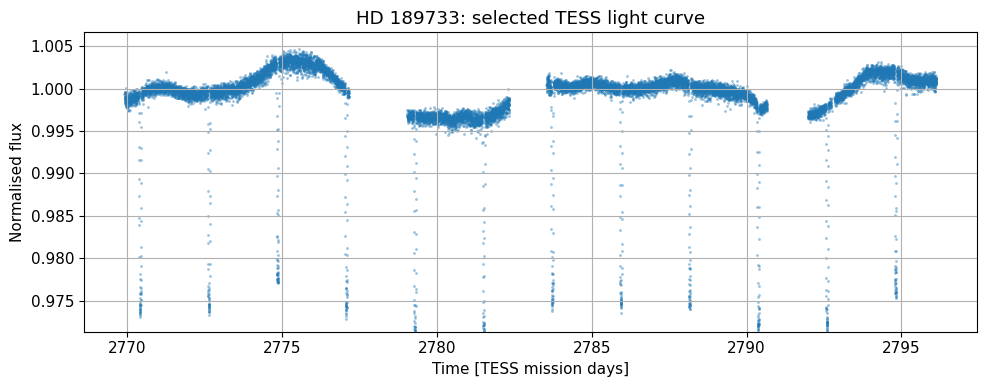

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.scatter(
    lc.time.value,
    lc.flux.value,
    s=4,
    alpha=0.45,
    linewidths=0
)

ax.set_title(f"{HOST_STAR}: selected TESS light curve")
ax.set_xlabel("Time [TESS mission days]")
ax.set_ylabel("Normalised flux")

lo, hi = np.nanpercentile(lc.flux.value, [1, 99])
ax.set_ylim(lo - 0.003, hi + 0.003)

fig.tight_layout()
fig.savefig(OUTDIR / "01_selected_tess_light_curve.png", dpi=250)
plt.show()

## 7. Fold and bin the selected light curve

The transit is recovered by folding the observed flux values at the known orbital period.

In [9]:
folded = lc.fold(period=PERIOD_DAYS, epoch_time=EPOCH_TIME)
binned = folded.bin(time_bin_size=BIN_MINUTES * u.minute)

phase_hr = np.asarray(folded.time.value, dtype=float) * 24.0
flux = np.asarray(folded.flux.value, dtype=float)

bin_phase_hr = np.asarray(binned.time.value, dtype=float) * 24.0
bin_flux = np.asarray(binned.flux.value, dtype=float)

depth_fraction, depth_percent, depth_ppm, n_folded = measure_depth_for_epoch(
    lc, EPOCH_TIME, PERIOD_DAYS, DURATION_HOURS, PLOT_WINDOW_HOURS
)

print("Folded points:", n_folded)
print(f"Measured depth ≈ {depth_percent:.3f}%")
print(f"Measured depth ≈ {depth_ppm:.0f} ppm")
if REFERENCE_DEPTH_PERCENT is not None:
    print(f"Reference/archive depth ≈ {REFERENCE_DEPTH_PERCENT:.3f}%")

Folded points: 15580
Measured depth ≈ 2.236%
Measured depth ≈ 22356 ppm
Reference/archive depth ≈ 2.410%


## 8. Final folded transit plot

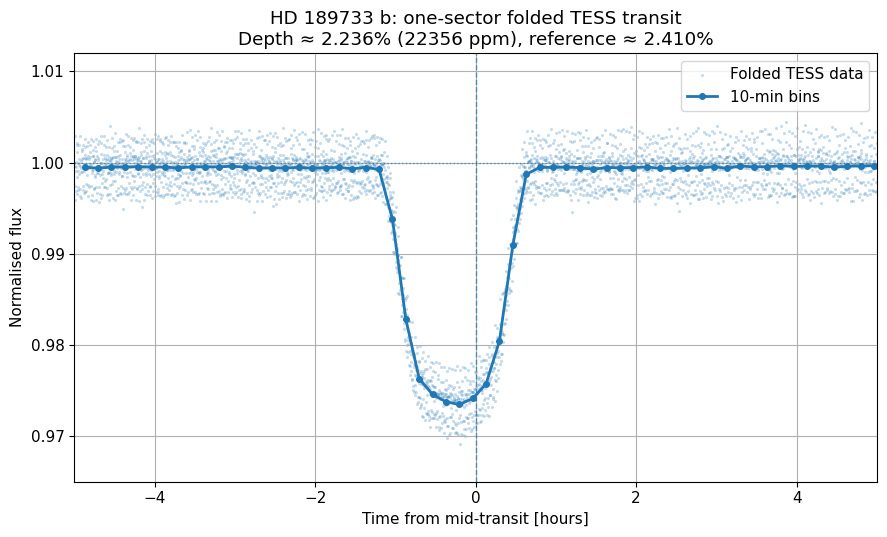

,target,planet,product_index_used,period_days,duration_hours,epoch_time_used,measured_depth_percent,measured_depth_ppm,reference_depth_percent
0,HD 189733,HD 189733 b,1,2.218576,1.823362,2783.73301,2.235587,22355.873605,2.41


In [10]:
zoom = np.abs(phase_hr) < PLOT_WINDOW_HOURS
zoom_bin = np.abs(bin_phase_hr) < PLOT_WINDOW_HOURS

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.scatter(
    phase_hr[zoom],
    flux[zoom],
    s=5,
    alpha=0.25,
    linewidths=0,
    label="Folded TESS data"
)

ax.plot(
    bin_phase_hr[zoom_bin],
    bin_flux[zoom_bin],
    "o-",
    linewidth=2,
    markersize=4,
    label=f"{BIN_MINUTES}-min bins"
)

ax.axvline(0, linestyle="--", linewidth=1, alpha=0.7)
ax.axhline(1, linestyle=":", linewidth=1, alpha=0.7)

ax.set_xlim(-PLOT_WINDOW_HOURS, PLOT_WINDOW_HOURS)
ax.set_ylim(0.965, 1.012)

title = (
    f"{PLANET_NAME}: one-sector folded TESS transit\n"
    f"Depth ≈ {depth_percent:.3f}% ({depth_ppm:.0f} ppm)"
)

if REFERENCE_DEPTH_PERCENT is not None:
    title += f", reference ≈ {REFERENCE_DEPTH_PERCENT:.3f}%"

ax.set_title(title)
ax.set_xlabel("Time from mid-transit [hours]")
ax.set_ylabel("Normalised flux")
ax.legend()

fig.tight_layout()
fig.savefig(OUTDIR / "02_folded_transit.png", dpi=300)
plt.show()

summary = pd.DataFrame([{
    "target": HOST_STAR,
    "planet": PLANET_NAME,
    "product_index_used": PRODUCT_INDEX_USED,
    "period_days": PERIOD_DAYS,
    "duration_hours": DURATION_HOURS,
    "epoch_time_used": EPOCH_TIME,
    "measured_depth_percent": depth_percent,
    "measured_depth_ppm": depth_ppm,
    "reference_depth_percent": REFERENCE_DEPTH_PERCENT
}])

display(summary)
summary.to_csv(OUTDIR / "transit_depth_summary.csv", index=False)

## 9. Estimate physical properties from the dip

The simplest transit-depth relation is:

$$
\delta \approx \left(\frac{R_p}{R_\star}\right)^2
$$

So:

$$
\frac{R_p}{R_\star} \approx \sqrt{\delta}
$$

If the stellar radius is known:

$$
R_p \approx R_\star \sqrt{\delta}
$$

These are first-order estimates, not a full transit model.

In [11]:
if depth_fraction > 0:
    measured_rp_rs = np.sqrt(depth_fraction)
else:
    measured_rp_rs = np.nan

if np.isfinite(measured_rp_rs) and np.isfinite(STELLAR_RADIUS_RSUN):
    measured_rp = measured_rp_rs * STELLAR_RADIUS_RSUN * const.R_sun
    measured_rp_rearth = (measured_rp / const.R_earth).decompose().value
    measured_rp_rjup = (measured_rp / const.R_jup).decompose().value
else:
    measured_rp_rearth = np.nan
    measured_rp_rjup = np.nan

if np.isfinite(PLANET_MASS_MJUP) and np.isfinite(measured_rp_rjup):
    mass = PLANET_MASS_MJUP * const.M_jup
    radius = measured_rp_rjup * const.R_jup
    volume = (4 / 3) * np.pi * radius**3
    density_g_cm3 = (mass / volume).to(u.g / u.cm**3).value
else:
    density_g_cm3 = np.nan

if np.isfinite(SEMI_MAJOR_AXIS_AU):
    semi_major_axis = SEMI_MAJOR_AXIS_AU * u.au
    semi_major_axis_au = SEMI_MAJOR_AXIS_AU
elif np.isfinite(STELLAR_MASS_MSUN) and np.isfinite(PERIOD_DAYS):
    period = PERIOD_DAYS * u.day
    stellar_mass = STELLAR_MASS_MSUN * const.M_sun
    semi_major_axis = ((const.G * stellar_mass * period**2) / (4 * np.pi**2))**(1/3)
    semi_major_axis = semi_major_axis.to(u.au)
    semi_major_axis_au = semi_major_axis.value
else:
    semi_major_axis = np.nan
    semi_major_axis_au = np.nan

if np.isfinite(STELLAR_TEFF_K) and np.isfinite(STELLAR_RADIUS_RSUN) and hasattr(semi_major_axis, "unit"):
    stellar_radius = STELLAR_RADIUS_RSUN * const.R_sun
    equilibrium_temp_k = STELLAR_TEFF_K * np.sqrt((stellar_radius / (2 * semi_major_axis)).decompose().value)
else:
    equilibrium_temp_k = np.nan

if np.isfinite(measured_rp_rs) and np.isfinite(STELLAR_RADIUS_RSUN) and hasattr(semi_major_axis, "unit"):
    stellar_radius = STELLAR_RADIUS_RSUN * const.R_sun
    planet_radius = measured_rp_rs * stellar_radius
    transit_probability_percent = ((stellar_radius + planet_radius) / semi_major_axis).decompose().value * 100
else:
    transit_probability_percent = np.nan

physical_table = pd.DataFrame({
    "Quantity": [
        "Host star",
        "Planet",
        "Discovery method",
        "Distance [pc]",
        "Orbital period [days]",
        "Transit duration [hours]",
        "Measured transit depth [%]",
        "Measured transit depth [ppm]",
        "Measured Rp/Rs from dip",
        "Archive Rp/Rs",
        "Estimated planet radius from dip [R_earth]",
        "Estimated planet radius from dip [R_jup]",
        "Archive planet radius [R_earth]",
        "Archive planet radius [R_jup]",
        "Archive planet mass [M_jup]",
        "Estimated bulk density [g/cm3]",
        "Semi-major axis [AU]",
        "Orbital inclination [deg]",
        "Stellar radius [R_sun]",
        "Stellar mass [M_sun]",
        "Stellar effective temperature [K]",
        "Approx. equilibrium temperature [K]",
        "Approx. transit probability [%]"
    ],
    "Value": [
        HOST_STAR,
        PLANET_NAME,
        archive.get("discoverymethod", ""),
        DISTANCE_PC,
        PERIOD_DAYS,
        DURATION_HOURS,
        depth_percent,
        depth_ppm,
        measured_rp_rs,
        RP_RS_ARCHIVE,
        measured_rp_rearth,
        measured_rp_rjup,
        ARCHIVE_RP_REARTH,
        ARCHIVE_RP_RJUP,
        PLANET_MASS_MJUP,
        density_g_cm3,
        semi_major_axis_au,
        ORBITAL_INCLINATION_DEG,
        STELLAR_RADIUS_RSUN,
        STELLAR_MASS_MSUN,
        STELLAR_TEFF_K,
        equilibrium_temp_k,
        transit_probability_percent
    ]
})

display(physical_table)

physical_table.to_csv(OUTDIR / "physical_properties_from_transit.csv", index=False)
print("Saved:", OUTDIR / "physical_properties_from_transit.csv")

,Quantity,Value
0,Host star,HD 189733
1,Planet,HD 189733 b
2,Discovery method,Radial Velocity
3,Distance [pc],19.7638
4,Orbital period [days],2.218576
5,Transit duration [hours],1.823362
6,Measured transit depth [%],2.235587
7,Measured transit depth [ppm],22355.873605
8,Measured Rp/Rs from dip,0.149519
9,Archive Rp/Rs,0.15534


Saved: outputs/physical_properties_from_transit.csv


## 10. Quick interpretation

In [12]:
print(f"Quick interpretation for {PLANET_NAME}")
print()
print(f"Measured depth: {depth_percent:.3f}% ({depth_ppm:.0f} ppm)")
print(f"Measured radius ratio: Rp/Rs ≈ {measured_rp_rs:.4f}")
print(f"Estimated planet radius: {measured_rp_rearth:.2f} R_earth")
print(f"Estimated planet radius: {measured_rp_rjup:.2f} R_jup")
print()
print("Archive comparison:")
print(f"Archive Rp/Rs ≈ {RP_RS_ARCHIVE:.4f}")
print(f"Archive planet radius ≈ {ARCHIVE_RP_RJUP:.2f} R_jup")
print()
print("This is a first-order one-sector recovery, not a full transit fit.")

Quick interpretation for HD 189733 b

Measured depth: 2.236% (22356 ppm)
Measured radius ratio: Rp/Rs ≈ 0.1495
Estimated planet radius: 12.23 R_earth
Estimated planet radius: 1.09 R_jup

Archive comparison:
Archive Rp/Rs ≈ 0.1553
Archive planet radius ≈ 1.13 R_jup

This is a first-order one-sector recovery, not a full transit fit.


## 11. Save outputs

In [13]:
import shutil

zip_path = shutil.make_archive("hd189733b_transit_photometry_outputs", "zip", OUTDIR)
print("Created:", zip_path)

Created: /content/hd189733b_transit_photometry_outputs.zip


## 12. Notes for experimenting

If you want to try another planet:

1. change `TARGET_KEY`,
2. rerun the notebook,
3. inspect the product table,
4. if no useful dip appears, increase `MAX_PRODUCTS_TO_TEST`,
5. if you want manual control, set `AUTO_SELECT_PRODUCT = False` and change `MANUAL_PRODUCT_INDEX`.

Possible later upgrades:

- sector-by-sector comparison,
- BLS period search,
- local transit-window normalisation,
- `batman` transit model,
- limb-darkening coefficients,
- uncertainty estimation.

## 13. References

Bakos, G. Á. et al. (2006) ‘Refined parameters of the planet orbiting HD 189733’, *The Astrophysical Journal*.

Bouchy, F. et al. (2005) ‘ELODIE metallicity-biased search for transiting Hot Jupiters II. A very hot Jupiter transiting the bright K star HD 189733’, *Astronomy & Astrophysics*.

Lightkurve Collaboration et al. (2018) ‘Lightkurve: Kepler and TESS time series analysis in Python’, *Astrophysics Source Code Library*.

NASA Exoplanet Archive (n.d.) ‘Planetary Systems Composite Parameters and TAP service’, NASA Exoplanet Science Institute.

Pont, F. et al. (2007) ‘Hubble Space Telescope time-series photometry of the planetary transit of HD 189733: no moon, no rings, starspots’, *Astronomy & Astrophysics*.

Ricker, G. R. et al. (2015) ‘Transiting Exoplanet Survey Satellite’, *Journal of Astronomical Telescopes, Instruments, and Systems*.